In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp
from tqdm import tqdm
from utils import plot_3d_trajectory, plot_observations
from utils import solve_lorenz
from utils import evaluate
from utils import plot_estim_evolution
from utils import sgd_update
from utils import compute_snr
import optuna

In [2]:
import configparser

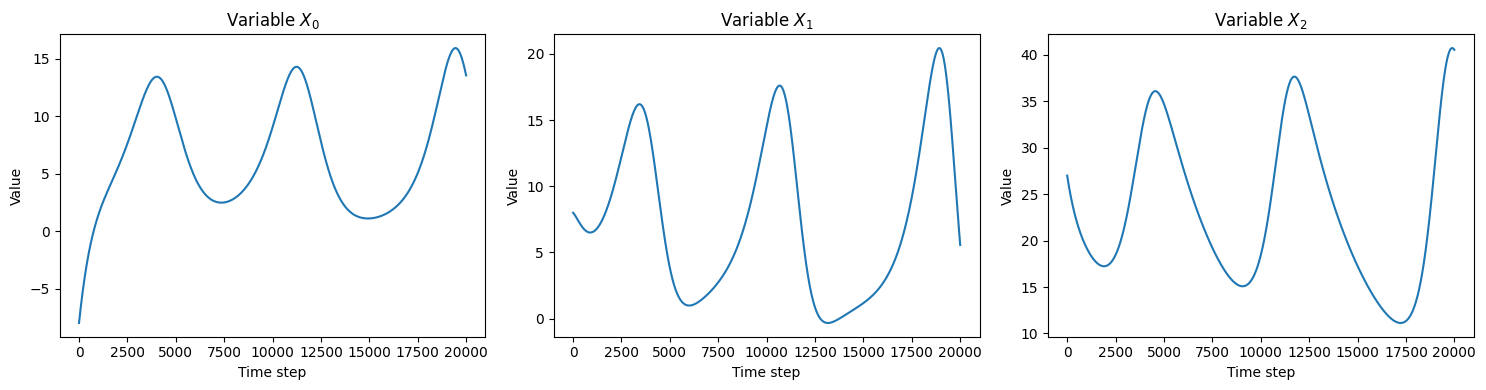

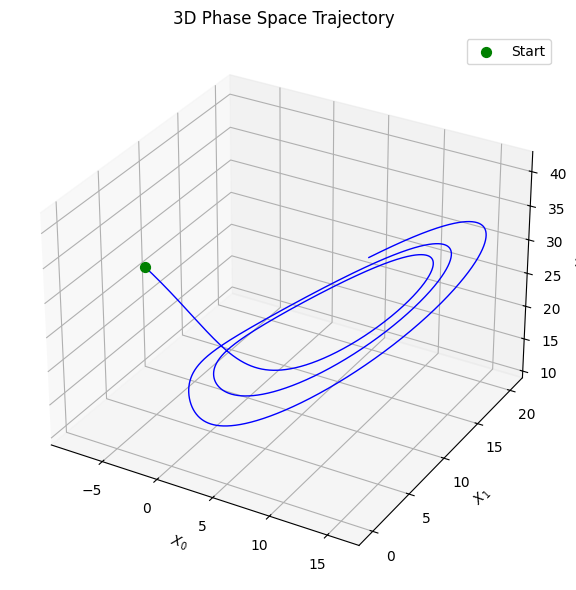

In [3]:
def f(X, theta):
    return np.array([theta[0]*X[1] - theta[0]*X[0],
                     theta[1]*X[0] - X[0]*X[2] - X[1],
                     X[0]*X[1] - theta[2]*X[2]])

def runge_kutta4(f, X_n, theta, h):
    k1 = f(X_n, theta)
    k2 = f(X_n + h*k1/2, theta)
    k3 = f(X_n + h*k2/2, theta)
    k4 = f(X_n + h*k3, theta)
    return X_n + h*(k1 + 2*k2 + 2*k3 + k4)/6

X_0 = np.array([-8.0, 8.0, 27.0], dtype=np.float64)
theta = np.array([10.0, 28.0, 8.0/3.0], dtype=np.float64)

t_0, t_f = 0, 2
h = 1e-4
N = int((t_f-t_0)/h)

observations = np.zeros((N, 3))
observations[0] = np.array(X_0)

for n in range(N-1):
    observations[n+1] = runge_kutta4(f, observations[n], theta, h)

observations_solver = solve_lorenz(t_0=t_0, t_f=t_f, dt=h, X_0=X_0)
plot_observations(observations)
plot_3d_trajectory(observations)

In [4]:
def compute_grad(f, methode, theta_estim, A, estim_obs, n):
    sum_term = np.dot(estim_obs[:n], A).sum(axis=0)   

    X_nm1 = estim_obs[n-1]
    X_n   = estim_obs[n] 
    
    error = methode(f, X_nm1, theta_estim, h) -  X_n
    # error = h * f(X_nm1, theta_estim) + X_nm1 -  X_n

    grad = sum_term * error
    return grad


In [5]:
def decay_lr(lr, epoch, decay = 1e-4): 
    return lr

In [6]:
def decay_grad(grads, current_grad_idx, clip_value=np.array([25,10,10]), window=40, decay=0.8):

    grad = grads[current_grad_idx]

    # --- soft clipping ---
    grad = clip_value * np.tanh(grad / clip_value)
    grads[current_grad_idx] = grad

    # --- window selection ---
    start = max(0, current_grad_idx - window + 1)
    window_grads = grads[start:current_grad_idx + 1]

    # --- exponential decay weights ---
    n = len(window_grads)
    weights = decay ** np.arange(n)[::-1]
    weights = weights / np.sum(weights)

    # --- weighted average ---
    smoothed_grad = np.sum(window_grads * weights[:, None], axis=0)

    # grad_norm = smoothed_grad / (np.linalg.norm(smoothed_grad) + 1e-8)

    return smoothed_grad

In [7]:
def decay_grad(grads, current_grad_idx, clip_value=np.array([25,10,10]), window=40, decay=0.8):

    grad = grads[current_grad_idx]

    grads[current_grad_idx] = grad

    # --- window selection ---
    start = max(0, current_grad_idx - window + 1)
    window_grads = grads[start:current_grad_idx + 1]

    # --- normalize each gradient BEFORE smoothing ---
    norms = np.linalg.norm(window_grads, axis=1, keepdims=True) + 1e-8
    window_grads_norm = window_grads / norms


    # --- weighted average of normalized grads ---
    smoothed_grad = np.sum(window_grads_norm, axis=0)

    return smoothed_grad


In [ ]:
def main(window = 40, 
         decay = 0.8, 
         epochs = 2,
         var = 0.01,
         noise_level=0.5,
         lr = np.array([1e-3, 1e-3, 1e-3]), 
         clip_value = np.array([25,10,10])): 
    
    theta_estim = np.array([-5.0, -3.0, 10.0])

    nbr_epochs = int(epochs * N)
    A = np.array([[-1, 1, 0],
                [1 , 0, 0],
                [0 , 0, -1]])

    estim_obs = observations.copy() + noise_level*np.random.normal(0, var, (N, 3))

    theta_estim_vec = np.zeros((nbr_epochs, 3))
    theta_estim_vec[0] = theta_estim

    grads = np.zeros((nbr_epochs, 3))
    gra = np.zeros((nbr_epochs, 3))

    for epoch in tqdm(range(1, nbr_epochs)):
        n = epoch % N
        grad = compute_grad(f, runge_kutta4, theta_estim, A, estim_obs, n)
        grads[epoch, :] = grad
        gra[epoch, :] = grad
        grad = decay_grad(grads, epoch, clip_value, window, decay)
        theta_estim = sgd_update(theta_estim, grad, lr)
        lr = decay_lr(lr, epoch)
        theta_estim_vec[epoch] = theta_estim
    
    return theta_estim, theta_estim_vec, grads, gra

In [31]:
theta_estim, theta_estim_vec, grads, gra = main()

  0%|          | 0/39999 [00:00<?, ?it/s]

100%|██████████| 39999/39999 [00:47<00:00, 846.82it/s] 


In [20]:
def plot_grads(grads, var_names=None):
    var_names = [r'$\frac{\partial X_0}{\partial t}$',
                 r'$\frac{\partial X_1}{\partial t}$', 
                 r'$\frac{\partial X_2}{\partial t}$']

    time = np.arange(grads.shape[0])
    plt.figure(figsize=(15, 4))

    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.plot(time, grads[:, i])
        plt.title(var_names[i])
        plt.xlabel('Time step')
        plt.ylabel('Value')
    
    plt.tight_layout()
    plt.show()

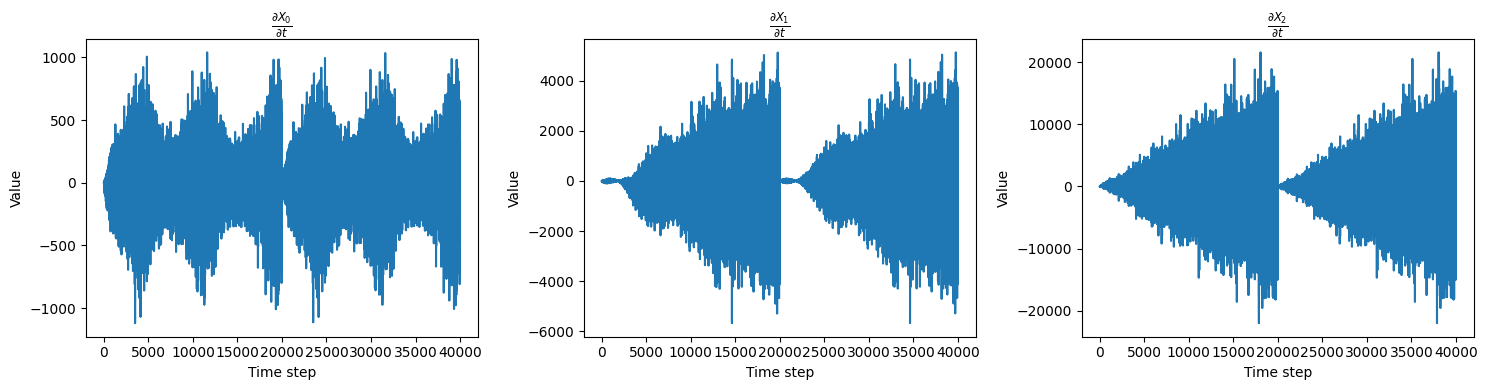

In [21]:
plot_grads(gra)

L'erreur relative sur σ, ρ, β est de : 2.633155%, 0.062166%, 2.645840%


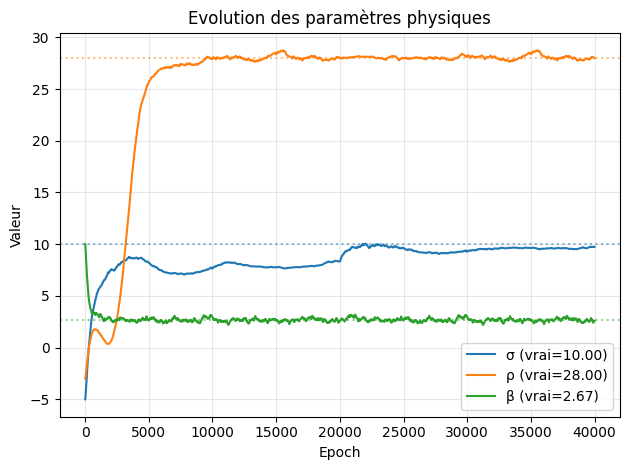

In [33]:
sigma, rho, beta = evaluate(theta_estim, theta)

plot_estim_evolution(theta_estim_vec, theta)

In [ ]:
config = configparser.ConfigParser()
config.read('config.ini')
param_snr = 'Params_var_01_'
noise_var = config[param_snr].getfloat('var')
noise_level = 0.5

snr = compute_snr(observations, noise_var)
print(f"SNR (dB) for each dimension: {snr}")
print(f"Average SNR (dB): {np.mean(snr):.2f}")

SNR (dB) for each dimension: [33.80576899 35.48211877 38.15715361]
Average SNR (dB): 35.82


In [23]:
window = config[param_snr].getint('window')
decay = config[param_snr].getfloat('decay')
nbr_epochs = config[param_snr].getfloat('nbr_epochs')
lr_0 = config[param_snr].getfloat('lr_0')
lr_1 = config[param_snr].getfloat('lr_1')
lr_2 = config[param_snr].getfloat('lr_2')
clip_0 = config[param_snr].getfloat('clip_0')
clip_1 = config[param_snr].getfloat('clip_1')
clip_2 = config[param_snr].getfloat('clip_2')

In [ ]:
theta_estim, theta_estim_vec, grads, gra = main(window, 
                                           decay, 
                                           nbr_epochs, 
                                           noise_var,
                                           noise_level,
                                           np.array([lr_0, lr_1, lr_2]), 
                                           np.array([clip_0, clip_1, clip_2]))

  1%|          | 395/64726 [00:00<00:16, 3947.87it/s]

100%|██████████| 64726/64726 [01:16<00:00, 851.22it/s] 


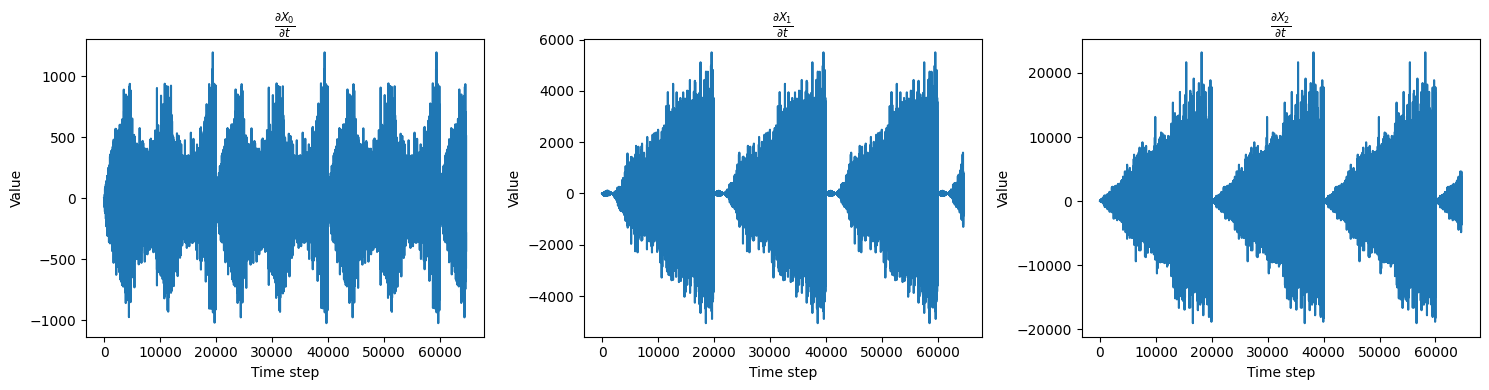

In [25]:
plot_grads(grads)

L'erreur relative sur σ, ρ, β est de : 11.557383%, 0.320277%, 5.050875%


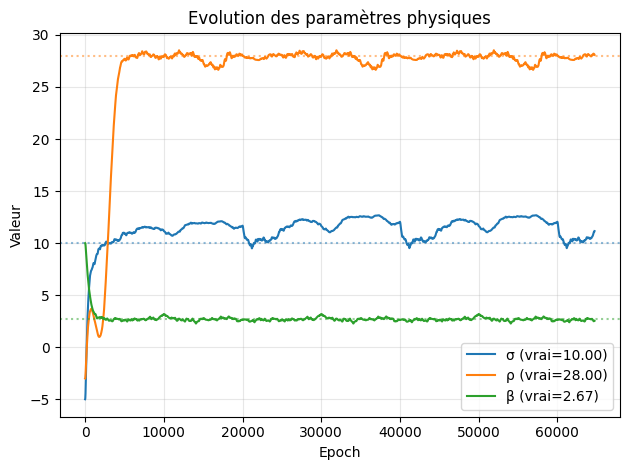

In [26]:
sigma, rho, beta = evaluate(theta_estim, theta)

plot_estim_evolution(theta_estim_vec, theta)

In [15]:
# https://github.com/scipy/scipy/blob/b2b7944064af15bd87e781216c2dfda7400ecd2d/scipy/integrate/_ivp/rk.py

In [16]:
# import numpy as np
# from scipy.integrate._ivp.rk import RK45

# # Initial condition
# X_0 = np.array([-8.0, 8.0, 27.0], dtype=np.float64)

# # Initial and final time
# t0 = 0.0
# t_bound = 10.0

# # Number of stored observations
# N = 50_000
# observations = np.zeros((N, 3))
# observations[0] = X_0

# # Create solver
# solver = RK45(lorenz, t0, X_0, t_bound,
#               rtol=1e-7, atol=1e-9,
#               max_step=np.inf)


# n = 0
# while solver.status == "running":
#     solver.step()
#     n += 1
#     observations[n] = solver.y
